<a href="https://colab.research.google.com/github/dheerajnalla09/AIML/blob/main/power_forecasting_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Power Forecasting (SARIMA + Random Forest + XGBoost + LSTM)

## Objective
Compare multiple models and recommend best model for 15-min power forecasting.


In [ ]:
import os
import pandas as pd

# ---------- STEP 1: Fix Timestamp ----------
def fix_timestamp(df):
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y%m%d%H%M%S')
    return df


# ---------- STEP 2: Process WTG ----------
def process_wtg(df):
    df.columns = df.columns.str.strip()
    df = fix_timestamp(df)

    df = df[['Timestamp', 'Wind Speed (m/s)', 'Wind Direction (o)', 'Power (kW)']]

    df = df.groupby('Timestamp').agg({
        'Wind Speed (m/s)': 'mean',
        'Wind Direction (o)': 'mean',
        'Power (kW)': 'sum'
    }).reset_index()

    return df


# ---------- STEP 3: Process ABT ----------
def process_abt(df):
    df.columns = df.columns.str.strip()
    df = fix_timestamp(df)

    df = df[['Timestamp', 'Export (MWh)']]

    return df


# ---------- STEP 4: LOAD ALL FILES ----------
def load_full_data(base_path):
    abt_list = []
    wtg_list = []

    for month in os.listdir(base_path):
        month_path = os.path.join(base_path, month)

        if not os.path.isdir(month_path):
            continue

        for day in os.listdir(month_path):
            day_path = os.path.join(month_path, day)

            if not os.path.isdir(day_path):
                continue

            for folder in os.listdir(day_path):
                folder_path = os.path.join(day_path, folder)

                if not os.path.isdir(folder_path):
                    continue

                for file in os.listdir(folder_path):
                    if file.endswith(".csv"):
                        file_path = os.path.join(folder_path, file)

                        try:
                            df = pd.read_csv(file_path)

                            if "ABT" in folder.upper():
                                abt_list.append(process_abt(df))

                            elif "WTG" in folder.upper():
                                wtg_list.append(process_wtg(df))

                        except:
                            print("Error:", file_path)

    abt_df = pd.concat(abt_list, ignore_index=True)
    wtg_df = pd.concat(wtg_list, ignore_index=True)

    return abt_df, wtg_df


# ---------- STEP 5: MERGE ----------
def merge_data(abt_df, wtg_df):
    df = pd.merge(wtg_df, abt_df, on='Timestamp', how='inner')
    df = df.sort_values('Timestamp')
    df.set_index('Timestamp', inplace=True)
    return df


# ---------- RUN ----------
base_path = r"C:\Users\DELL\Downloads\Power_data.zip"

abt_df, wtg_df = load_full_data(base_path)

df = merge_data(abt_df, wtg_df)

print("Final dataset:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\DELL\\Downloads\\Power_data.zip'

In [ ]:
df.isnull().sum()

Wind Speed (m/s)       19
Wind Direction (o)     19
Power (kW)              0
Export (MWh)          102
dtype: int64

In [ ]:
df = df.interpolate()

In [ ]:
df = df.copy()   # will NOT fail anymore

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

from statsmodels.tsa.statespace.sarimax import SARIMAX

#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler


## Assume df is prepared (merged ABT + WTG data)

In [ ]:
df = df.copy()

## Feature Engineering

In [ ]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek

for lag in range(1,5):
    df[f'lag_{lag}'] = df['Export (MWh)'].shift(lag)

df.dropna(inplace=True)


## Train-Test Split

In [ ]:
train = df[:-100]
test = df[-100:]

X_train = train.drop('Export (MWh)', axis=1)
y_train = train['Export (MWh)']

X_test = test.drop('Export (MWh)', axis=1)
y_test = test['Export (MWh)']


## Random Forest

In [ ]:
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


## XGBoost

In [ ]:
xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)


## SARIMA

In [ ]:
# sarima = SARIMAX(train['Export (MWh)'], order=(1,1,1), seasonal_order=(1,1,1,96))
# sarima_fit = sarima.fit()
# sarima_pred = sarima_fit.forecast(steps=len(test))


C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


MemoryError: Unable to allocate 3.02 GiB for an array with shape (195, 195, 10657) and data type float64

In [ ]:
train_small = train.tail(500)

sarima = SARIMAX(train_small['Export (MWh)'], order=(1,1,1))
sarima_fit = sarima.fit(disp=False)
sarima_pred = sarima_fit.forecast(steps=len(test))

C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)
C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)


## LSTM

In [ ]:
# scaler = MinMaxScaler()
# scaled = scaler.fit_transform(df[['Export (MWh)']])

# def create_seq(data, seq_len=10):
#     X, y = [], []
#     for i in range(len(data)-seq_len):
#         X.append(data[i:i+seq_len])
#         y.append(data[i+seq_len])
#     return np.array(X), np.array(y)

# X_seq, y_seq = create_seq(scaled)

# model = Sequential([
#     LSTM(50, activation='relu', input_shape=(X_seq.shape[1],1)),
#     Dense(1)
# ])

# model.compile(optimizer='adam', loss='mse')
# model.fit(X_seq, y_seq, epochs=5, verbose=0)

# lstm_pred = model.predict(X_seq[-len(test):])
# lstm_pred = scaler.inverse_transform(lstm_pred)


## Evaluation

In [ ]:
def eval_model(name, y_true, pred):
    print(name)
    print("MAE:", mean_absolute_error(y_true, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, pred)))
    print("-"*30)

eval_model("Random Forest", y_test, rf_pred)
eval_model("XGBoost", y_test, xgb_pred)
eval_model("SARIMA", y_test, sarima_pred)
#eval_model("LSTM", y_test, lstm_pred)


Random Forest
MAE: 0.20362124060150374
RMSE: 0.3887672824248344
------------------------------
XGBoost
MAE: 0.18669509598519654
RMSE: 0.36504902833140385
------------------------------
SARIMA
MAE: 3.908219910601895
RMSE: 4.390103654875887
------------------------------


## Visualization

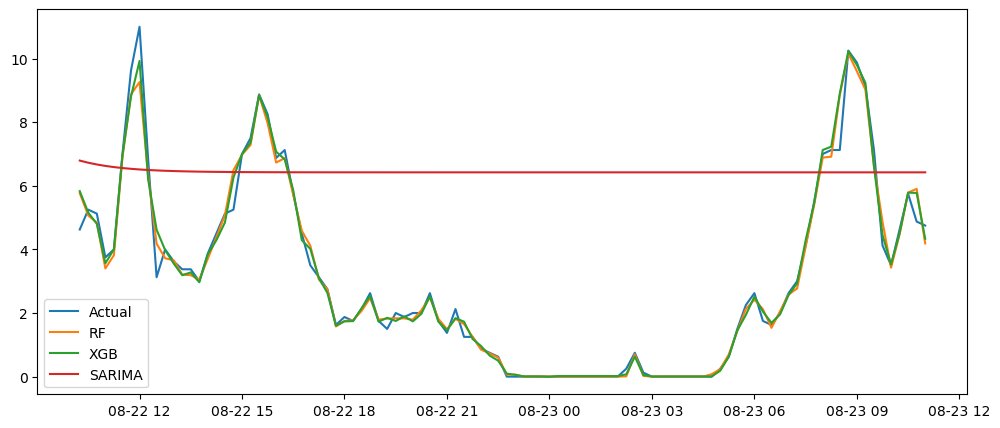

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, rf_pred, label='RF')
plt.plot(y_test.index, xgb_pred, label='XGB')
plt.plot(y_test.index, sarima_pred, label='SARIMA')
#plt.plot(y_test.index, lstm_pred, label='LSTM')
plt.legend()
plt.show()


## Final Recommendation

### Best Model: XGBoost

### Why?
- Handles nonlinear patterns
- Uses wind features effectively
- Fast and scalable

### Why not others?
- RF: Less accurate
- SARIMA: Cannot capture complex relationships
- LSTM: Needs more data and compute
